# Сравнение ROC-AUC метрик

Этот ноутбук сравнивает две интерпретации метрики без изменения проектного evaluator и тестов.

- **Текущий локальный evaluator**: повторяет `hackaton/eval/metric.py`: фиксированный TOP-10 пул, затем TOP-`capacity`, `max_fpr = min(1.0, capacity / 10)`.
- **Предполагаемая финальная проверка**: фиксированный TOP-10 пул, `roc_auc_score(..., max_fpr=0.1)`.

Задача остается задачей бинарной классификации и ранжирования: для каждой пары `(user_id, shift_id)` target `1` означает, что пользователь согласился выйти на смену (`APPLY` label). Качество оценивается через ROC-AUC, но с акцентом на верхнюю часть ранжированного списка.

Ноутбук умеет либо загрузить уже собранный prediction frame из кэша, либо собрать предсказания через RPC-сервис. Он не меняет `hackaton/eval/metric.py`.

In [ ]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import auc, roc_auc_score, roc_curve
from zero import ZeroClient

from hackaton.eval.evaluator import (
    EvalConfig,
    _build_day_prediction_frame,
    _load_csvs,
    _run_prepare_and_wait,
    _upload_events,
    _upload_shifts,
    _upload_users,
    _wait_until_ready_only,
)

ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd()
PROJECT_SITE_PACKAGES = ROOT / ".venv" / "lib" / "python3.12" / "site-packages"
for import_path in [PROJECT_SITE_PACKAGES, ROOT]:
    if import_path.exists() and str(import_path) not in sys.path:
        sys.path.insert(0, str(import_path))

pd.set_option("display.max_columns", 80)
plt.style.use("default")

## Конфигурация

Если `USE_CACHED_PREDICTIONS = True`, ноутбук читает `PREDICTION_CACHE` и не делает RPC-вызовы. Если файла еще нет, установите `USE_CACHED_PREDICTIONS = False`, запустите сервис в отдельном терминале и выполните ячейку сбора predictions.

Пример команды запуска сервиса:

```bash
APP_HOST=127.0.0.1 APP_PORT=8008 DB_PATH=./data/hackaton_notebook_8008.db PREPARE_SLEEP_SECONDS=0 poetry run python -m hackaton.service.main
```

In [4]:
HOST = "127.0.0.1"
PORT = 8008
PREDICT_MAX_RPM = 180
PREDICT_MAX_CONCURRENCY = 4
LIMIT = 10

USER_PATH = ROOT / "data/train_split/user.csv"
TRAIN_SHIFT_PATH = ROOT / "data/train_split/shift.csv"
TRAIN_EVENT_PATH = ROOT / "data/train_split/event.csv"
VAL_APPLY_PATH = ROOT / "data/validation/apply.csv"
VAL_SHIFT_PATH = ROOT / "data/validation/shift.csv"
VAL_EVENT_PATH = ROOT / "data/validation/event.csv"

OUTPUT_DIR = ROOT / "artifacts/notebook_metric_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_CACHE = OUTPUT_DIR / "predictions.csv"

USE_CACHED_PREDICTIONS = PREDICTION_CACHE.exists()

cfg = EvalConfig(
    host=HOST,
    port=PORT,
    user_path=str(USER_PATH),
    shift_path=str(TRAIN_SHIFT_PATH),
    event_path=str(TRAIN_EVENT_PATH),
    val_apply_path=str(VAL_APPLY_PATH),
    val_shift_path=str(VAL_SHIFT_PATH),
    val_event_path=str(VAL_EVENT_PATH),
    output_dir=str(OUTPUT_DIR),
    limit=LIMIT,
    predict_max_concurrency=PREDICT_MAX_CONCURRENCY,
    predict_max_rpm=PREDICT_MAX_RPM,
    poll_interval_sec=1,
)

cfg, PREDICTION_CACHE, USE_CACHED_PREDICTIONS

(EvalConfig(host='127.0.0.1', port=8008, user_path='/home/goddenis/hackaton-codex/ml-hackathon/data/train_split/user.csv', shift_path='/home/goddenis/hackaton-codex/ml-hackathon/data/train_split/shift.csv', event_path='/home/goddenis/hackaton-codex/ml-hackathon/data/train_split/event.csv', val_apply_path='/home/goddenis/hackaton-codex/ml-hackathon/data/validation/apply.csv', val_shift_path='/home/goddenis/hackaton-codex/ml-hackathon/data/validation/shift.csv', val_event_path='/home/goddenis/hackaton-codex/ml-hackathon/data/validation/event.csv', output_dir='/home/goddenis/hackaton-codex/ml-hackathon/artifacts/notebook_metric_comparison', limit=10, batch_size=1000, prepare_initial_timeout_sec=1200, prepare_day_timeout_sec=300, poll_interval_sec=1, rpc_timeout_ms=10000, predict_retry_on_not_ready=5, predict_max_concurrency=4, predict_max_rpm=180),
 PosixPath('/home/goddenis/hackaton-codex/ml-hackathon/artifacts/notebook_metric_comparison/predictions.csv'),
 False)

## Сбор или загрузка prediction frame

Prediction frame содержит одну строку на каждого предсказанного кандидата и колонки:

- `shift_id`
- `start_at`
- `capacity`
- `target`: `1`, если `(user_id, shift_id)` есть в `apply.csv`, иначе `0`
- `score`: proxy вероятности, полученный из ранга; кандидат на первом месте получает максимальный score

Это соответствует локальному eval pipeline: сервис возвращает ранжированный список `user_ids`, а evaluator преобразует ранги в scores перед расчетом ROC-AUC.

In [6]:
def collect_prediction_frame(cfg: EvalConfig) -> pd.DataFrame:
    users, train_shifts, train_events, val_apply, val_shifts, val_events = _load_csvs(cfg)
    client = ZeroClient(cfg.host, cfg.port, default_timeout=cfg.rpc_timeout_ms)
    all_frames = []
    try:
        print("Uploading bootstrap train data...")
        _upload_users(client, users, cfg.batch_size)
        _upload_shifts(client, train_shifts, cfg.batch_size)
        _upload_events(client, train_events, cfg.batch_size)
        print("Initial prepare...")
        _run_prepare_and_wait(client, cfg.prepare_initial_timeout_sec, cfg.poll_interval_sec)

        eval_days = sorted(d for d in val_apply["date"].dropna().unique())
        for day_idx, day in enumerate(eval_days, start=1):
            day_shifts = val_shifts[val_shifts["start_at"].dt.date == day].copy()
            day_apply = val_apply[val_apply["date"] == day].copy()
            if day_shifts.empty:
                continue

            print(f"{day_idx}/{len(eval_days)} {day}: predict {len(day_shifts)} shifts")
            _wait_until_ready_only(client, cfg.prepare_day_timeout_sec, cfg.poll_interval_sec)
            prediction_frame, _ = _build_day_prediction_frame(
                cfg=cfg,
                day_shifts=day_shifts,
                day_apply=day_apply,
                limit=cfg.limit,
            )
            prediction_frame["eval_date"] = str(day)
            all_frames.append(prediction_frame)

            day_events = val_events[val_events["ts"].dt.date == day].copy()
            _wait_until_ready_only(client, cfg.prepare_day_timeout_sec, cfg.poll_interval_sec)
            _upload_shifts(client, day_shifts, cfg.batch_size)
            if not day_events.empty:
                _upload_events(client, day_events, cfg.batch_size)
            _run_prepare_and_wait(client, cfg.prepare_day_timeout_sec, cfg.poll_interval_sec)

        if not all_frames:
            return pd.DataFrame(
                columns=["shift_id", "start_at", "capacity", "target", "score", "eval_date"]
            )
        return pd.concat(all_frames, ignore_index=True)
    finally:
        client.close()


if USE_CACHED_PREDICTIONS:
    predictions = pd.read_csv(PREDICTION_CACHE)
    predictions["start_at"] = pd.to_datetime(predictions["start_at"], utc=True, errors="coerce")
    print(f"Loaded cached predictions: {PREDICTION_CACHE}")
else:
    started = time.perf_counter()
    predictions = collect_prediction_frame(cfg)
    predictions.to_csv(PREDICTION_CACHE, index=False)
    print(f"Saved predictions to {PREDICTION_CACHE} in {time.perf_counter() - started:.1f}s")

predictions.head(), predictions.shape

07-May-26 12:24:17      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded users batch 1, accepted=1000
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded users batch 2, accepted=1000
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded users batch 3, accepted=1000
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded users batch 4, accepted=1000
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded users batch 5, accepted=1000
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded users batch 6, accepted=154
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded shifts batch 1, accepted=1000


Uploading bootstrap train data...


07-May-26 12:24:17      INFO     84944  evaluator > Uploaded shifts batch 2, accepted=1000
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded shifts batch 3, accepted=1000
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded shifts batch 4, accepted=1000
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded shifts batch 5, accepted=1000
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded shifts batch 6, accepted=1000
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded shifts batch 7, accepted=1000
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded shifts batch 8, accepted=1000
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded shifts batch 9, accepted=1000
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded shifts batch 10, accepted=1000
07-May-26 12:24:17      INFO     84944  evaluator > Uploaded shifts batch 11, accepted=1000
07-May-26 12:24:18      INFO     84944  evaluator > Uploaded shifts batch 12, accepted=1

Initial prepare...


07-May-26 12:25:05      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008


...

07-May-26 12:27:47      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:27:48      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:27:48      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:27:48      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:27:49      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:27:49      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:27:49      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:27:50      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:27:50      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:27:50      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:27:51      INFO     84944  client > Connected to server a

13/13 2026-02-28: predict 27 shifts


07-May-26 12:28:00      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:28:00      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:28:01      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:28:01      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:28:01      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:28:02      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:28:02      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:28:02      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:28:03      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:28:03      INFO     84944  client > Connected to server at tcp://127.0.0.1:8008
07-May-26 12:28:03      INFO     84944  client > Connected to server a

Saved predictions to /home/goddenis/hackaton-codex/ml-hackathon/artifacts/notebook_metric_comparison/predictions.csv in 239.9s


(  shift_id                  start_at  capacity  target  score   eval_date
 0    21320 2026-02-16 10:30:00+00:00         2       0    1.0  2026-02-16
 1    21320 2026-02-16 10:30:00+00:00         2       0    0.9  2026-02-16
 2    21320 2026-02-16 10:30:00+00:00         2       0    0.8  2026-02-16
 3    21320 2026-02-16 10:30:00+00:00         2       0    0.7  2026-02-16
 4    21320 2026-02-16 10:30:00+00:00         2       0    0.6  2026-02-16,
 (2640, 6))

## Реализации метрик

`roc_auc_score(..., max_fpr=...)` возвращает standardized partial ROC-AUC из scikit-learn. Это ключевой момент: обе формулы ниже основаны именно на ROC-AUC. Они отличаются только тем, какой top-пул берется в расчет и как выбирается `max_fpr`.

In [7]:
METRIC_POOL_SIZE = 10


def _safe_partial_auc(frame: pd.DataFrame, max_fpr: float) -> float | None:
    if frame.empty or frame["target"].nunique() < 2:
        return None
    return float(roc_auc_score(frame["target"], frame["score"], max_fpr=max_fpr))


def current_local_shift_metric(group: pd.DataFrame) -> float | None:
    capacity = int(max(1, group["capacity"].iloc[0]))
    pool = group.sort_values("score", ascending=False).head(METRIC_POOL_SIZE)
    top = pool.head(capacity)
    max_fpr = min(1.0, capacity / METRIC_POOL_SIZE)
    return _safe_partial_auc(top, max_fpr=max_fpr)


def possible_final_shift_metric(group: pd.DataFrame) -> float | None:
    pool = group.sort_values("score", ascending=False).head(METRIC_POOL_SIZE)
    return _safe_partial_auc(pool, max_fpr=0.1)


def aggregate_metric(
    frame: pd.DataFrame, shift_metric_fn
) -> tuple[float, pd.DataFrame, pd.DataFrame]:
    data = frame.copy()
    data["start_at"] = pd.to_datetime(data["start_at"], utc=True, errors="coerce")
    data["eval_date"] = data["start_at"].dt.date.astype(str)
    data["capacity"] = (
        pd.to_numeric(data["capacity"], errors="coerce").fillna(1).astype(int).clip(lower=1)
    )
    data["target"] = pd.to_numeric(data["target"], errors="coerce").fillna(0).astype(int)
    data["score"] = pd.to_numeric(data["score"], errors="coerce")
    data = data.dropna(subset=["eval_date", "capacity", "shift_id", "target", "score"])

    rows = []
    for (eval_date, capacity, shift_id), shift_df in data.groupby(
        ["eval_date", "capacity", "shift_id"]
    ):
        metric = shift_metric_fn(shift_df)
        if metric is None:
            continue
        rows.append(
            {
                "eval_date": eval_date,
                "capacity": int(capacity),
                "shift_id": str(shift_id),
                "shift_metric": float(metric),
            }
        )

    shift_metrics = pd.DataFrame(rows)
    if shift_metrics.empty:
        return 0.0, shift_metrics, pd.DataFrame(columns=["eval_date", "capacity", "group_metric"])

    group_metrics = (
        shift_metrics.groupby(["eval_date", "capacity"], as_index=False)["shift_metric"]
        .mean()
        .rename(columns={"shift_metric": "group_metric"})
    )
    day_metrics = group_metrics.groupby("eval_date", as_index=False)["group_metric"].mean()
    overall = float(day_metrics["group_metric"].mean())
    return overall, shift_metrics, group_metrics

## Overall-сравнение

По текущему прогону получились такие значения:

- текущий локальный evaluator: `0.957852`;
- предполагаемая финальная проверка с `max_fpr=0.1`: `0.754555`;
- разница: `-0.203297` относительно локальной метрики.

Важно: падение не означает, что модель стала хуже после пересчета. Это означает, что текущая локальная метрика и предполагаемая финальная проверка смотрят на разные срезы ранжирования. Локальная формула часто оценивает только TOP-`capacity`, а финальная гипотеза оценивает весь TOP-10 при низком FPR. Поэтому финальная метрика строже к качеству порядка внутри всех первых десяти кандидатов.

In [8]:
current_overall, current_shift_metrics, current_group_metrics = aggregate_metric(
    predictions,
    current_local_shift_metric,
)
possible_overall, possible_shift_metrics, possible_group_metrics = aggregate_metric(
    predictions,
    possible_final_shift_metric,
)

comparison = pd.DataFrame(
    [
        {
            "metric_variant": "текущий_локальный_evaluator",
            "overall_roc_auc": current_overall,
            "shift_metrics": len(current_shift_metrics),
            "group_metrics": len(current_group_metrics),
        },
        {
            "metric_variant": "гипотеза_финальной_проверки_max_fpr_0_1",
            "overall_roc_auc": possible_overall,
            "shift_metrics": len(possible_shift_metrics),
            "group_metrics": len(possible_group_metrics),
        },
    ]
)
comparison["delta_vs_current"] = comparison["overall_roc_auc"] - current_overall
comparison

,metric_variant,overall_roc_auc,shift_metrics,group_metrics,delta_vs_current
0,current_local_evaluator,0.957852,25,16,0.000000
1,possible_final_checker_max_fpr_0_1,0.754555,66,34,-0.203297


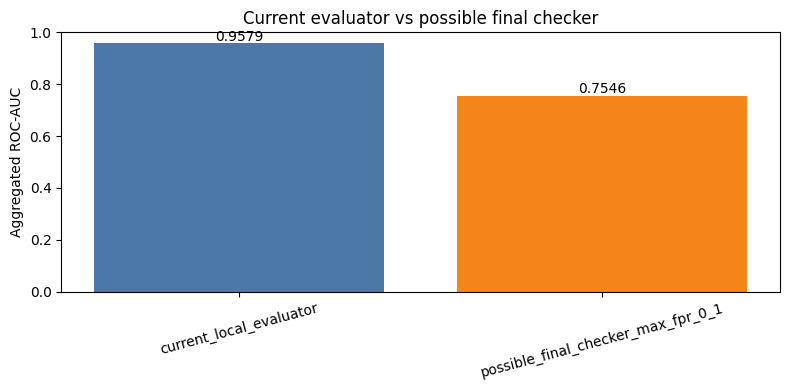

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comparison["metric_variant"], comparison["overall_roc_auc"], color=["#4C78A8", "#F58518"])
ax.set_ylabel("Агрегированный ROC-AUC")
ax.set_title("Текущий evaluator vs гипотеза финальной проверки")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=15)
for idx, value in enumerate(comparison["overall_roc_auc"]):
    ax.text(idx, value + 0.01, f"{value:.4f}", ha="center")
plt.tight_layout()
plt.show()

## Сравнение по группам

Таблица показывает, где две ROC-AUC интерпретации расходятся по дате и группе `capacity`.

По результатам видно, что для многих групп с `capacity=1` локальная метрика дает `NaN`, потому что после обрезки до TOP-`capacity` остается один кандидат и ROC-AUC невозможно посчитать без двух классов. Предполагаемая финальная проверка использует TOP-10, поэтому для таких групп появляется больше оцениваемых смен. В этом прогоне локальная формула посчитала метрику для `25` смен, а вариант TOP-10/`max_fpr=0.1` — для `66` смен.

In [10]:
group_comparison = current_group_metrics.rename(
    columns={"group_metric": "current_group_roc_auc"}
).merge(
    possible_group_metrics.rename(columns={"group_metric": "possible_final_group_roc_auc"}),
    on=["eval_date", "capacity"],
    how="outer",
)
group_comparison["delta"] = (
    group_comparison["possible_final_group_roc_auc"] - group_comparison["current_group_roc_auc"]
)
group_comparison.sort_values(["eval_date", "capacity"]).head(30)

,eval_date,capacity,current_group_roc_auc,possible_final_group_roc_auc,delta
0,2026-02-16,1,NaN,0.649123,NaN
1,2026-02-16,4,1.000000,1.000000,0.000000
2,2026-02-17,1,NaN,0.824561,NaN
3,2026-02-17,3,NaN,0.473684,NaN
4,2026-02-17,4,1.000000,1.000000,0.000000
5,2026-02-18,1,NaN,0.649123,NaN
6,2026-02-18,2,0.444444,0.473684,0.029240
7,2026-02-18,3,0.411765,0.473684,0.061920
8,2026-02-18,4,1.000000,1.000000,0.000000
9,2026-02-19,1,NaN,1.000000,NaN


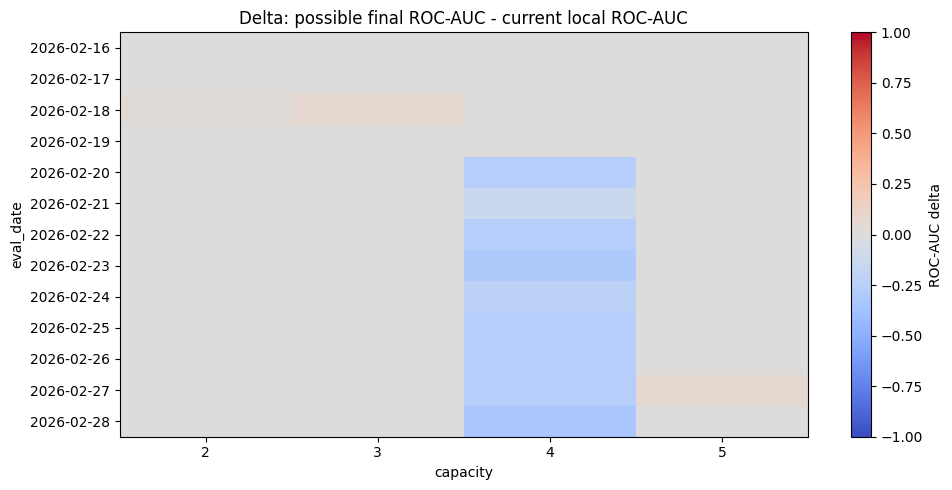

In [11]:
if not group_comparison.empty:
    pivot = group_comparison.pivot_table(
        index="eval_date", columns="capacity", values="delta", aggfunc="mean"
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(pivot.fillna(0).to_numpy(), aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("capacity")
    ax.set_ylabel("eval_date")
    ax.set_title("Delta: финальная гипотеза ROC-AUC - локальный ROC-AUC")
    fig.colorbar(im, ax=ax, label="Delta ROC-AUC")
    plt.tight_layout()
    plt.show()
else:
    print("No group metrics to plot")

## ROC-кривые для отдельных смен

Графики ниже показывают, почему задача именно про качество ранжирования ROC-AUC, а не только про бинарные метки. Для нескольких смен с двумя классами в TOP-10 строится ROC-кривая. Вертикальная линия `FPR = 0.1` показывает область, на которой делает акцент предполагаемая финальная проверка.

In [12]:
eligible_shift_ids = []
for shift_id, shift_df in predictions.groupby("shift_id"):
    pool = shift_df.sort_values("score", ascending=False).head(METRIC_POOL_SIZE)
    if pool["target"].nunique() == 2:
        eligible_shift_ids.append(shift_id)

sample_shift_ids = eligible_shift_ids[:6]
len(eligible_shift_ids), sample_shift_ids

(66, ['11421', '12232', '13997', '14627', '15493', '17390'])

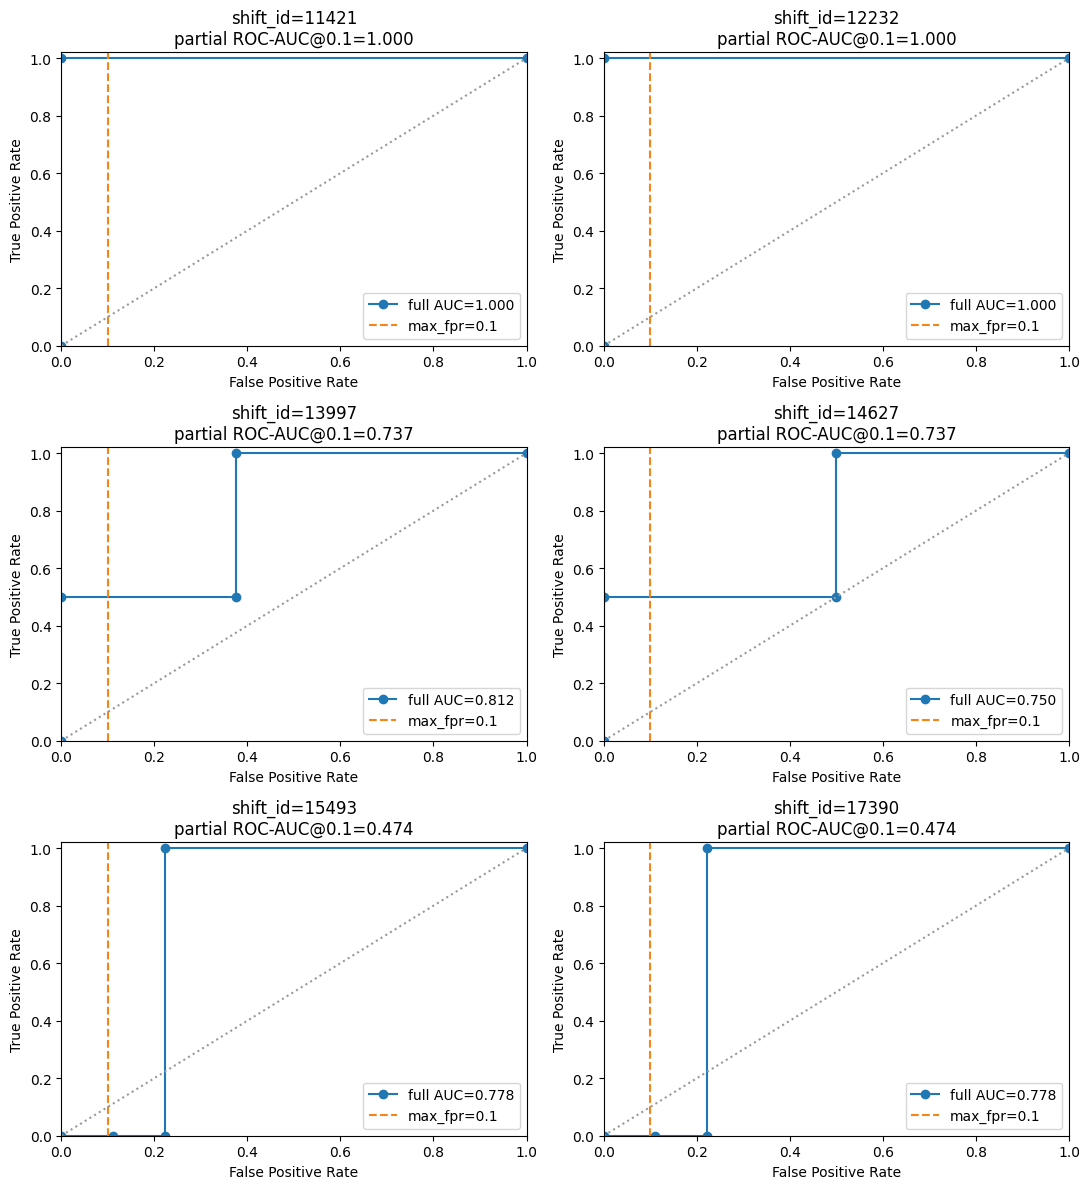

In [13]:
if sample_shift_ids:
    ncols = 2
    nrows = int(np.ceil(len(sample_shift_ids) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(11, 4 * nrows), squeeze=False)
    for ax, shift_id in zip(axes.ravel(), sample_shift_ids):
        pool = (
            predictions[predictions["shift_id"] == shift_id]
            .sort_values("score", ascending=False)
            .head(METRIC_POOL_SIZE)
        )
        fpr, tpr, _ = roc_curve(pool["target"], pool["score"])
        full_auc = auc(fpr, tpr)
        partial_auc = roc_auc_score(pool["target"], pool["score"], max_fpr=0.1)
        ax.plot(fpr, tpr, marker="o", label=f"full AUC={full_auc:.3f}")
        ax.axvline(0.1, color="#F58518", linestyle="--", label="max_fpr=0.1")
        ax.plot([0, 1], [0, 1], color="#999999", linestyle=":")
        ax.set_title(f"shift_id={shift_id}\npartial ROC-AUC@0.1={partial_auc:.3f}")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        ax.legend(loc="lower right")
    for ax in axes.ravel()[len(sample_shift_ids) :]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No shifts with both classes in TOP-10 predictions")

## Выводы и интерпретация

- Обе метрики основаны на `roc_auc_score`; это не accuracy, precision и не recall.
- Сервис возвращает только ранги, поэтому ноутбук использует тот же rank-derived score, что и локальный evaluator.
- В текущем прогоне в prediction frame `2640` строк, `264` смены и `96` positive-кандидатов в TOP-10 выдачах.
- Локальная метрика `0.957852` выглядит очень высокой, но она оптимистична относительно гипотезы финальной проверки: оцениваемых смен меньше (`25` против `66`), а TOP-10 часто дополнительно режется до `capacity`.
- Предполагаемая ROC-AUC@`max_fpr=0.1` равна `0.754555`. Это более строгий сигнал по качеству ранжирования внутри всего TOP-10.
- Если финальная проверка действительно использует фиксированный `max_fpr=0.1`, дальнейшие улучшения стоит нацеливать не только на первых `capacity` кандидатов, а на порядок всех первых 10 позиций.
- Практический критерий для следующих экспериментов: локальный evaluator должен не проседать, но основным дополнительным анализом стоит считать TOP-10 ROC-AUC@0.1 из этого ноутбука.